# Enhanced Spatial Analysis

**Author: Rohan Raval**

**Objectives:**
1. Service quality metrics (weight by size/capacity)
2. Network distance analysis (walking/transit times)
3. Getis-Ord Gi* hotspot analysis
4. Walkability/isochrone analysis

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats
from libpysal.weights import Queen
from esda.getisord import G_Local
import networkx as nx
import osmnx as ox

pd.set_option('display.max_columns', 120)

candidates = [Path("."), Path(".."), Path("../..")]
for cand in candidates:
    if (cand / "data" / "processed").exists():
        PROJECT_ROOT = cand.resolve()
        break

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_SERVICES = DATA_DIR / "processed" / "services"
PROCESSED_ACS = DATA_DIR / "processed" / "acs5" / "2023"
TIGER_DIR = DATA_DIR / "external" / "tiger_tracts_2023"

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/rohanraval/Documents/GitHub/Mapping-Youth-Opportunity-Deserts


## Load Data

In [8]:
services = pd.read_csv(PROCESSED_SERVICES / "services_master_enhanced.csv")
metrics = pd.read_csv(PROCESSED_ACS / "tract_opportunity_desert_metrics_2023.csv", dtype={"GEOID": str})

shp_path = TIGER_DIR / "tl_2023_06_tract.shp"
zip_path = TIGER_DIR / "tl_2023_06_tract.zip"
tracts_gdf = gpd.read_file(shp_path if shp_path.exists() else f"zip://{zip_path}")
sd_tracts = tracts_gdf[tracts_gdf["COUNTYFP"] == "073"].copy()
sd_tracts["GEOID"] = sd_tracts["GEOID"].astype(str)

sd_tracts = sd_tracts.merge(metrics, on="GEOID", how="left")
sd_tracts = sd_tracts.to_crs("EPSG:4326")

print(f"Services: {len(services)}")
print(f"Tracts: {len(sd_tracts)}")

Services: 520
Tracts: 912


## 1. Service Quality Metrics

In [9]:
def calculate_service_quality(df):
    df = df.copy()
    df["quality_score"] = 1.0
    
    if "sq_ft" in df.columns:
        sq_ft_norm = df["sq_ft"].fillna(0) / 10000
        df.loc[df["service_type"] == "rec_center", "quality_score"] += sq_ft_norm
    
    if "acres" in df.columns:
        acres_norm = df["acres"].fillna(0) / 10
        df.loc[df["service_type"] == "park", "quality_score"] += acres_norm
    
    facility_cols = ["playground", "basketball", "tennis", "multi_purpose"]
    for col in facility_cols:
        if col in df.columns:
            df["quality_score"] += df[col].fillna(0) * 0.5
    
    df.loc[df["youth_serving"] == True, "quality_score"] *= 1.5
    
    df.loc[df["service_type"] == "library", "quality_score"] = 2.0
    df.loc[df["service_type"] == "ymca", "quality_score"] = 3.0
    
    return df

services = calculate_service_quality(services)

print("Quality scores by type:")
print(services.groupby("service_type")["quality_score"].describe())

Quality scores by type:
              count      mean        std    min       25%       50%       75%  \
service_type                                                                    
library       130.0  2.000000   0.000000  2.000  2.000000  2.000000  2.000000   
park          306.0  3.916898  24.452112  1.000  1.116494  1.513309  2.155893   
rec_center     61.0  3.190055   1.050426  1.683  2.445000  3.121200  3.756000   
ymca           23.0  3.000000   0.000000  3.000  3.000000  3.000000  3.000000   

                     max  
service_type              
library         2.000000  
park          411.914768  
rec_center      7.195500  
ymca            3.000000  


In [10]:
services_geo = services.dropna(subset=["lat", "lon"]).copy()
services_gdf = gpd.GeoDataFrame(
    services_geo,
    geometry=gpd.points_from_xy(services_geo["lon"], services_geo["lat"]),
    crs="EPSG:4326"
)

services_metric = services_gdf.to_crs("EPSG:3857")
tracts_metric = sd_tracts.to_crs("EPSG:3857")

services_in_tracts = gpd.sjoin(services_metric, tracts_metric[["GEOID", "geometry"]], how="left", predicate="within")

weighted_counts = (
    services_in_tracts.groupby("GEOID", dropna=False)
    .agg(
        services_total=("name", "count"),
        quality_weighted_total=("quality_score", "sum"),
        avg_quality=("quality_score", "mean")
    )
    .reset_index()
)

sd_tracts = sd_tracts.merge(weighted_counts, on="GEOID", how="left")
sd_tracts["quality_weighted_total"] = sd_tracts["quality_weighted_total"].fillna(0)

sd_tracts["quality_weighted_per_1k_youth"] = (
    sd_tracts["quality_weighted_total"] / sd_tracts["youth_10_19"].replace({0: np.nan}) * 1000
)

print("Quality-weighted metrics added to tracts")
print(sd_tracts[["GEOID", "services_total", "quality_weighted_total", "quality_weighted_per_1k_youth"]].head())

Quality-weighted metrics added to tracts


KeyError: "['services_total'] not in index"

## 2. Network Distance Analysis

In [11]:
san_diego_bbox = (32.54, -117.25, 33.00, -116.95)

print("Downloading San Diego street network (this may take a few minutes)...")
G = ox.graph_from_bbox(
    north=san_diego_bbox[2], south=san_diego_bbox[0],
    east=san_diego_bbox[3], west=san_diego_bbox[1],
    network_type="walk"
)

print(f"Network loaded: {len(G.nodes)} nodes, {len(G.edges)} edges")

TypeError: graph_from_bbox() got an unexpected keyword argument 'north'

In [12]:
def calculate_isochrone(G, point, trip_time_minutes=15, speed_kmh=5):
    node = ox.distance.nearest_nodes(G, point[0], point[1])
    
    trip_time_seconds = trip_time_minutes * 60
    meters_per_minute = speed_kmh * 1000 / 60
    
    for u, v, k, data in G.edges(keys=True, data=True):
        data['time'] = data['length'] / meters_per_minute
    
    subgraph = nx.ego_graph(G, node, radius=trip_time_seconds, distance='time')
    return subgraph

sample_services = services_gdf[services_gdf["youth_serving"]].head(10)

isochrones = []
for idx, svc in sample_services.iterrows():
    try:
        iso = calculate_isochrone(G, (svc.geometry.x, svc.geometry.y), trip_time_minutes=15)
        iso_poly = ox.utils_graph.graph_to_gdfs(iso, nodes=False).unary_union.convex_hull
        isochrones.append({
            "name": svc["name"],
            "service_type": svc["service_type"],
            "geometry": iso_poly
        })
    except:
        continue

isochrones_gdf = gpd.GeoDataFrame(isochrones, crs="EPSG:4326")
print(f"Generated {len(isochrones_gdf)} 15-minute walk isochrones")

ValueError: Assigning CRS to a GeoDataFrame without a geometry column is not supported. Supply geometry using the 'geometry=' keyword argument, or by providing a DataFrame with column name 'geometry'

NameError: name 'isochrones_gdf' is not defined

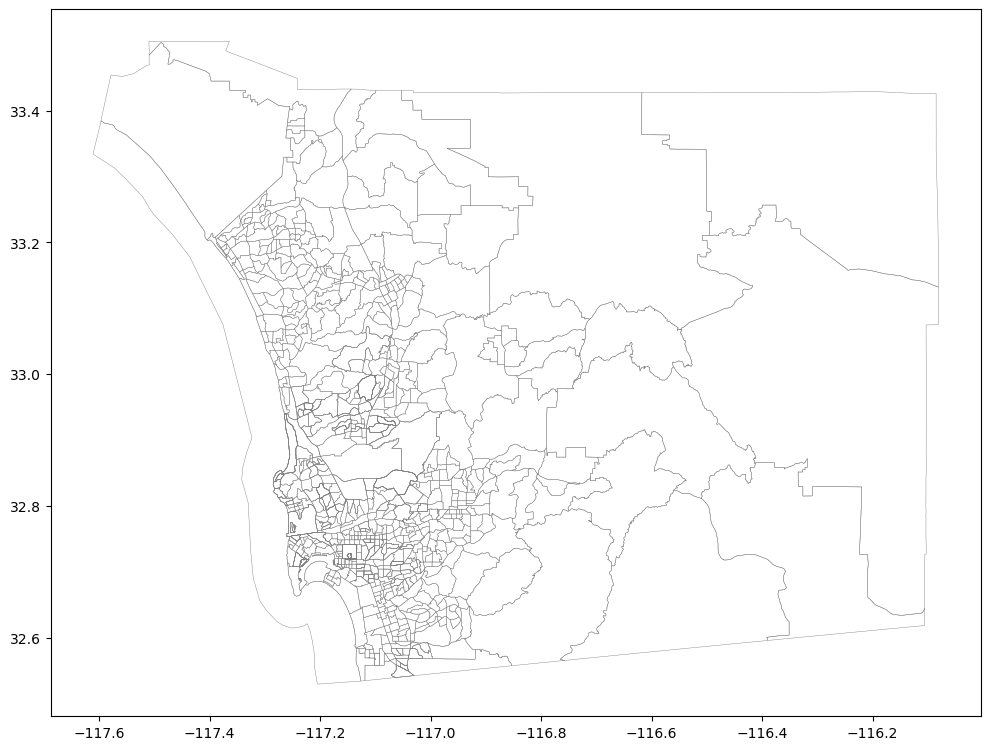

In [13]:
fig, ax = plt.subplots(figsize=(12, 10))

sd_tracts.boundary.plot(ax=ax, linewidth=0.3, edgecolor="grey")
isochrones_gdf.plot(ax=ax, alpha=0.3, color="blue", edgecolor="blue")
sample_services.plot(ax=ax, color="red", markersize=50, label="Services")

ax.set_title("15-Minute Walking Isochrones from Sample Youth Services")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Getis-Ord Gi* Hotspot Analysis

In [ ]:
tracts_clean = sd_tracts.dropna(subset=["services_per_1k_youth_10_19", "geometry"]).copy()
tracts_clean = tracts_clean[tracts_clean.geometry.is_valid]

w = Queen.from_dataframe(tracts_clean)
w.transform = 'r'

print(f"Spatial weights matrix: {w.n} observations")

In [ ]:
y = tracts_clean["services_per_1k_youth_10_19"].values
lg = G_Local(y, w)

tracts_clean["gi_star"] = lg.Zs
tracts_clean["gi_pvalue"] = lg.p_sim

tracts_clean["hotspot_type"] = "Not Significant"
tracts_clean.loc[(tracts_clean["gi_star"] > 1.96) & (tracts_clean["gi_pvalue"] < 0.05), "hotspot_type"] = "Hot Spot (High Services)"
tracts_clean.loc[(tracts_clean["gi_star"] < -1.96) & (tracts_clean["gi_pvalue"] < 0.05), "hotspot_type"] = "Cold Spot (Low Services)"

print("\nHotspot classification:")
print(tracts_clean["hotspot_type"].value_counts())

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

colors = {
    "Hot Spot (High Services)": "red",
    "Cold Spot (Low Services)": "blue",
    "Not Significant": "lightgrey"
}

for htype, color in colors.items():
    subset = tracts_clean[tracts_clean["hotspot_type"] == htype]
    subset.plot(ax=ax, color=color, edgecolor="black", linewidth=0.3, label=htype, alpha=0.7)

ax.set_title("Getis-Ord Gi* Hotspot Analysis: Youth Service Access")
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
cold_spots = tracts_clean[tracts_clean["hotspot_type"] == "Cold Spot (Low Services)"].copy()

print(f"\nCold Spot Tracts (n={len(cold_spots)}):")
print(cold_spots[[
    "NAME", "youth_10_19", "services_per_1k_youth_10_19",
    "median_hh_income_2023usd", "zero_veh_share", "gi_star"
]].sort_values("gi_star").head(10))

## Save Enhanced Metrics

In [ ]:
output_path = PROCESSED_ACS / "tract_enhanced_metrics_2023.csv"
tracts_clean[[
    "GEOID", "NAME", "services_per_1k_youth_10_19",
    "quality_weighted_per_1k_youth", "gi_star", "gi_pvalue", "hotspot_type"
]].to_csv(output_path, index=False)

print(f"Saved: {output_path}")

services.to_csv(PROCESSED_SERVICES / "services_with_quality.csv", index=False)
print(f"Saved: {PROCESSED_SERVICES / 'services_with_quality.csv'}")